In [ ]:
# 把所有信号整合，做出第一份分析报告
# 目标是把之前所有的东西整合成一个可复用的分析函数，以后对任何东证股票一行代码就能生成完整分析图。

[*********************100%***********************]  1 of 1 completed


  7203.T 分析报告
  区间收益率   : -1.9%
  年化波动率   : 33.5%
  当前 RSI     : 39.4
  信号总数     : 5 个
  金叉日期     : ['2024-10-28', '2024-12-12']
  死叉日期     : ['2024-10-18', '2024-11-27', '2025-01-20']


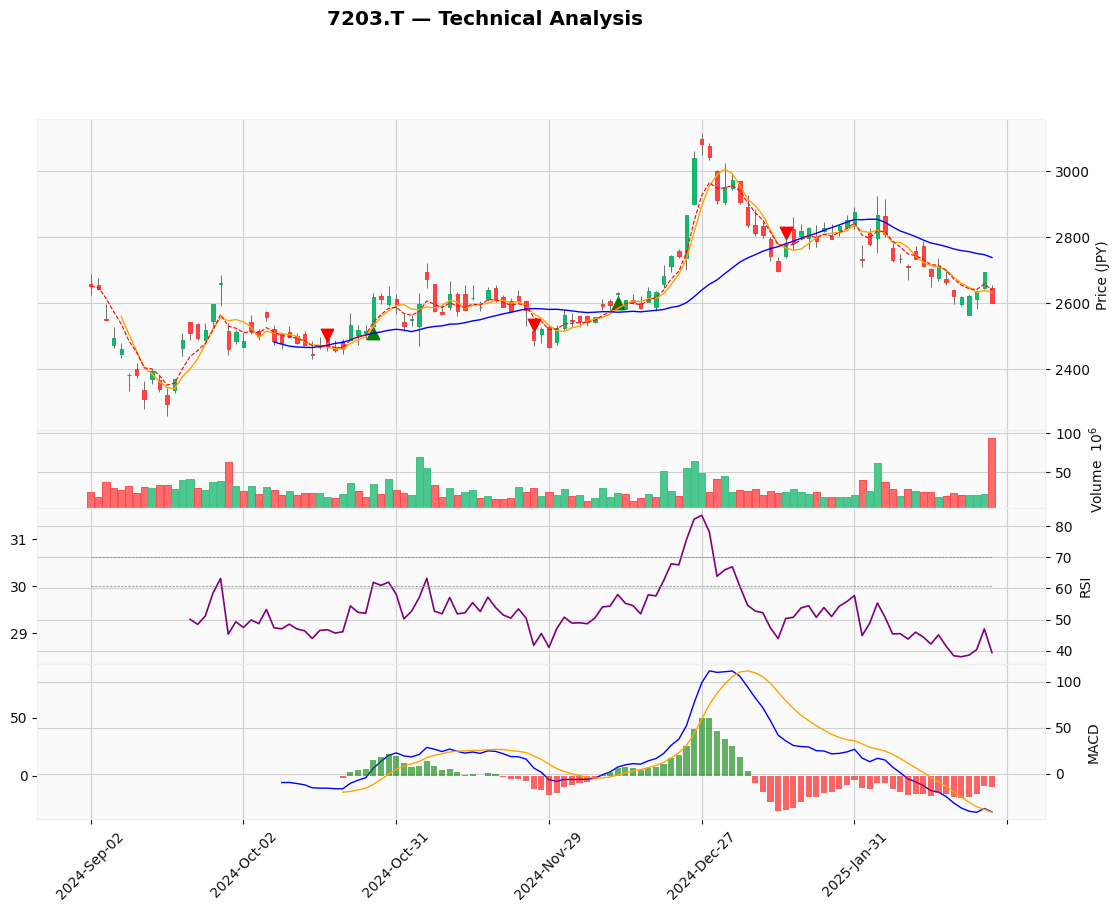

[*********************100%***********************]  1 of 1 completed


  9984.T 分析报告
  区间收益率   : -2.2%
  年化波动率   : 45.4%
  当前 RSI     : 31.7
  信号总数     : 9 个
  金叉日期     : ['2024-12-05', '2025-01-06', '2025-01-22', '2025-02-04']
  死叉日期     : ['2024-11-18', '2024-12-24', '2025-01-16', '2025-02-03', '2025-02-21']


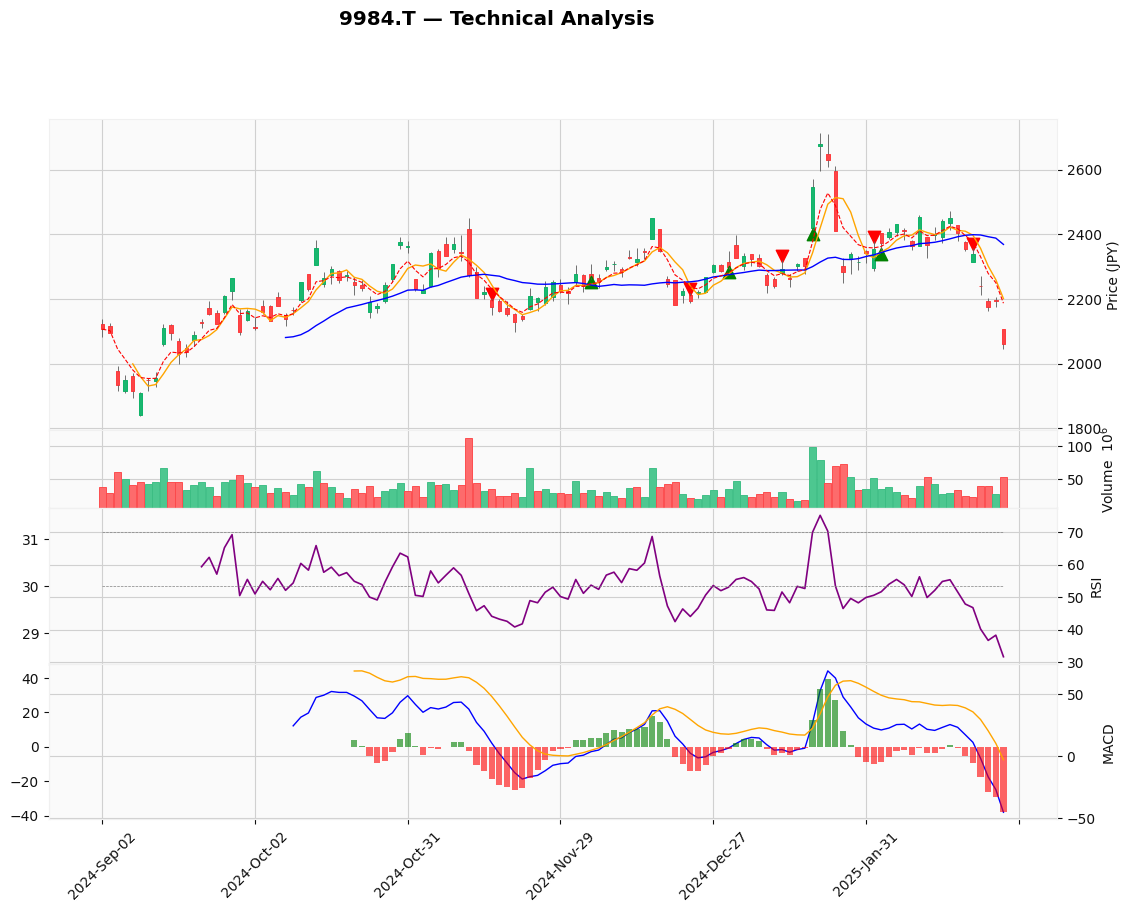

[*********************100%***********************]  1 of 1 completed


  6758.T 分析报告
  区间收益率   : +33.2%
  年化波动率   : 30.9%
  当前 RSI     : 60.7
  信号总数     : 4 个
  金叉日期     : ['2024-11-11', '2025-01-28']
  死叉日期     : ['2024-10-22', '2025-01-10']


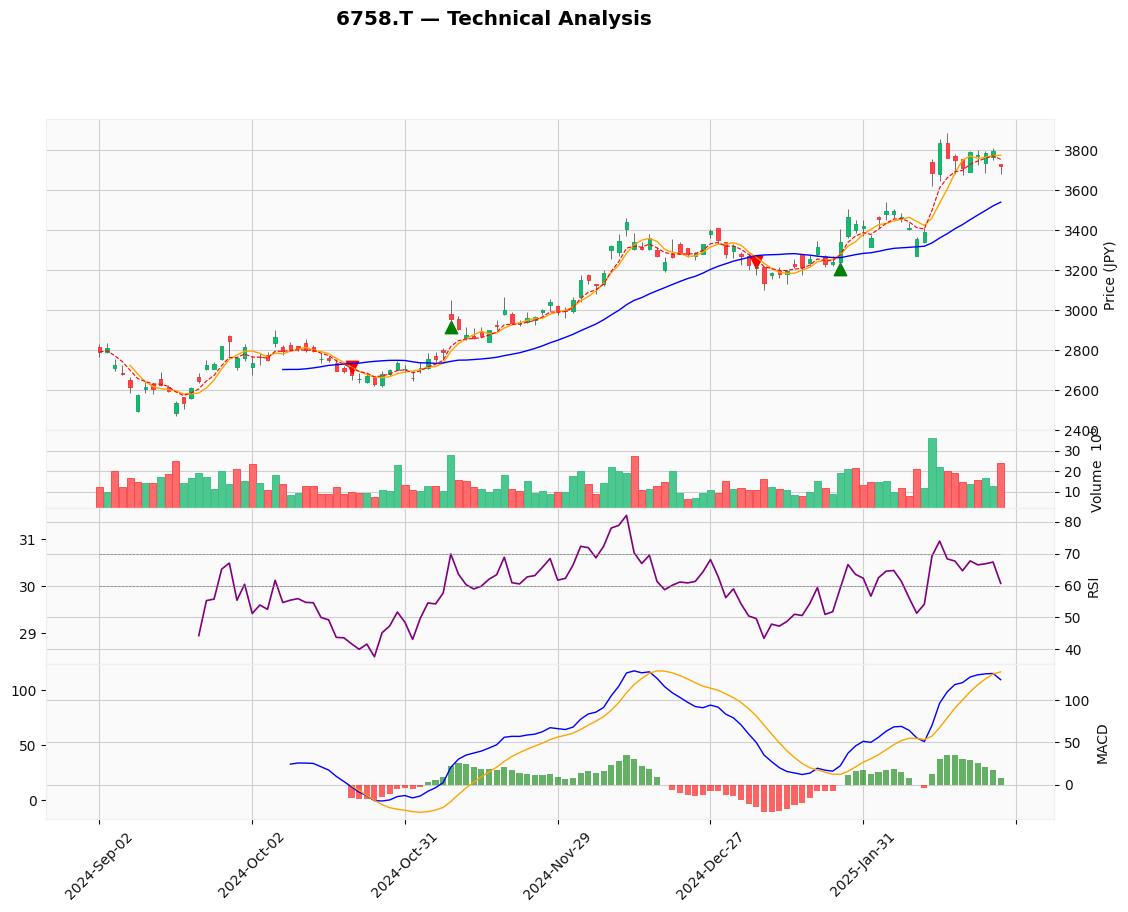

In [1]:
import yfinance as yf
import pandas as pd
import mplfinance as mpf
import ta
import numpy as np

def analyze_stock(ticker, start="2024-09-01", end="2025-03-01"):
    """
    东证股票技术分析一键函数
    用法: analyze_stock("7203.T")
    """
    # ── 1. 数据获取 ──────────────────────────────────
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df.columns = df.columns.droplevel(1) if df.columns.nlevels > 1 else df.columns
    df.dropna(inplace=True)

    # ── 2. 指标计算 ──────────────────────────────────
    df["SMA5"]        = df["Close"].rolling(5).mean()
    df["SMA25"]       = df["Close"].rolling(25).mean()
    df["EMA5"]        = df["Close"].ewm(span=5, adjust=False).mean()
    df["RSI14"]       = ta.momentum.RSIIndicator(df["Close"], window=14).rsi()
    macd              = ta.trend.MACD(df["Close"])
    df["MACD"]        = macd.macd()
    df["MACD_signal"] = macd.macd_signal()
    df["MACD_hist"]   = macd.macd_diff()

    # ── 3. 信号检测 ──────────────────────────────────
    prev = df["SMA5"].shift(1) - df["SMA25"].shift(1)
    curr = df["SMA5"] - df["SMA25"]
    golden = (prev < 0) & (curr > 0)
    death  = (prev > 0) & (curr < 0)

    buy_markers  = np.where(golden, df["Low"]  * 0.995, np.nan)
    sell_markers = np.where(death,  df["High"] * 1.005, np.nan)

    # ── 4. 统计摘要 ──────────────────────────────────
    total_return = (df["Close"].iloc[-1] / df["Close"].iloc[0] - 1) * 100
    volatility   = df["Close"].pct_change().std() * np.sqrt(252) * 100
    current_rsi  = df["RSI14"].iloc[-1]
    signal_count = golden.sum() + death.sum()

    print("=" * 45)
    print(f"  {ticker} 分析报告")
    print("=" * 45)
    print(f"  区间收益率   : {total_return:+.1f}%")
    print(f"  年化波动率   : {volatility:.1f}%")
    print(f"  当前 RSI     : {current_rsi:.1f}")
    print(f"  信号总数     : {signal_count} 个")
    print(f"  金叉日期     : {df[golden].index.strftime('%Y-%m-%d').tolist()}")
    print(f"  死叉日期     : {df[death].index.strftime('%Y-%m-%d').tolist()}")
    print("=" * 45)

    # ── 5. 可视化 ────────────────────────────────────
    rsi_ob      = [70] * len(df)
    rsi_os      = [30] * len(df)
    hist_colors = ["green" if v >= 0 else "red"
                   for v in df["MACD_hist"].fillna(0)]

    add_plots = [
        mpf.make_addplot(df["SMA5"],      color="orange", width=1.0, panel=0),
        mpf.make_addplot(df["SMA25"],     color="blue",   width=1.0, panel=0),
        mpf.make_addplot(df["EMA5"],      color="red",    width=0.8,
                         panel=0, linestyle="dashed"),
        mpf.make_addplot(buy_markers,     type="scatter", markersize=80,
                         marker="^",     color="green",  panel=0),
        mpf.make_addplot(sell_markers,    type="scatter", markersize=80,
                         marker="v",     color="red",    panel=0),
        mpf.make_addplot(df["RSI14"],     color="purple", width=1.2,
                         panel=2, ylabel="RSI"),
        mpf.make_addplot(rsi_ob,          color="gray",   width=0.5,
                         panel=2, linestyle="dashed"),
        mpf.make_addplot(rsi_os,          color="gray",   width=0.5,
                         panel=2, linestyle="dashed"),
        mpf.make_addplot(df["MACD"],      color="blue",   width=1.0,
                         panel=3, ylabel="MACD"),
        mpf.make_addplot(df["MACD_signal"],color="orange",width=1.0, panel=3),
        mpf.make_addplot(df["MACD_hist"], type="bar",     panel=3,
                         color=hist_colors, alpha=0.6),
    ]

    mpf.plot(
        df,
        type="candle",
        volume=True,
        addplot=add_plots,
        style="yahoo",
        title=f"{ticker} — Technical Analysis",
        ylabel="Price (JPY)",
        figsize=(14, 10),
        panel_ratios=(4, 1, 2, 2),
    )

    return df


# ── 用3支股票测试 ────────────────────────────────────
for ticker in ["7203.T", "9984.T", "6758.T"]:  # トヨタ・ソフトバンク・ソニー
    df = analyze_stock(ticker)
    print()